In [ ]:
import time
from sage.combinat.finite_state_machine import FSMState, FSMTransition

GenData=load("GenDataDict.sobj")
ShadowData=load("ShadowData.sobj")
OldData=load("OldData.sobj")


GenMin=dict()
ShadowMin=dict()
OldMin=dict()

Coeffs=[2,3,4,5,-1]
l=len(Coeffs)
testVal=True
r=0
for i in range(l):
    for j in range(i,l):
        for k in range(j,l):
            print(f"Considering {(Coeffs[i],Coeffs[j],Coeffs[k])}")
            print("Unminimized Sizes:")
            FSA=GenData[(Coeffs[i],Coeffs[j],Coeffs[k])][0]
            FSA.determine_input_alphabet()
            print(f"Generalized: {FSA}")

            sFSA=ShadowData[(Coeffs[i],Coeffs[j],Coeffs[k])][0]
            sFSA.determine_input_alphabet()
            print(f"Shadow:      {sFSA}")

            oFSA=OldData[(Coeffs[i],Coeffs[j],Coeffs[k])][0]
            oFSA.determine_input_alphabet()
            print(f"Old:         {oFSA}")
            r=r+1

            print("Minimized Sizes:")
            B=FSA.minimization()
            GenMin[(Coeffs[i],Coeffs[j],Coeffs[k])]=B
            print(f"Generalized: {B}")

            sB=sFSA.minimization()
            ShadowMin[(Coeffs[i],Coeffs[j],Coeffs[k])]=sB
            print(f"Shadow:      {sB}")

            oB=oFSA.minimization()
            OldMin[(Coeffs[i],Coeffs[j],Coeffs[k])]=oB
            print(f"Old:         {oB}")
            
            if B.is_equivalent(sB):
                print("Minimized Shadow and Generalized agree.")
            else:
                print("MINIMIZED SHADOW AND GENERALIZED DID NOT AGREE")

            if B.is_equivalent(oB):
                print("minimized Old and Generalized agree.")
            else:
                print("MINIMIZED OLD AND GENERALIZED DID NOT AGREE")

            if oB.is_equivalent(sB):
                print("Minimized Shadow and Old agree.")
            else:
                print("MINIMIZED SHADOW AND OLD DID NOT AGREE")
            print(" ")
            print(" ")
                
save(GenMin,"GenMinData")
save(ShadowMin,"ShadowMinData")
save(OldMin,"OldMinData")

Considering (2, 2, 2)
Unminimized Sizes:
Generalized: Automaton with 26 states
Shadow:      Automaton with 26 states
Old:         Automaton with 26 states
Minimized Sizes:
Generalized: Automaton with 9 states
Shadow:      Automaton with 9 states
Old:         Automaton with 9 states
Minimized Shadow and Generalized agree.
minimized Old and Generalized agree.
Minimized Shadow and Old agree.
 
 
Considering (2, 2, 3)
Unminimized Sizes:
Generalized: Automaton with 58 states
Shadow:      Automaton with 58 states
Old:         Automaton with 62 states
Minimized Sizes:
Generalized: Automaton with 13 states
Shadow:      Automaton with 13 states
Old:         Automaton with 13 states
Minimized Shadow and Generalized agree.
minimized Old and Generalized agree.
Minimized Shadow and Old agree.
 
 
Considering (2, 2, 4)
Unminimized Sizes:
Generalized: Automaton with 108 states
Shadow:      Automaton with 108 states
Old:         Automaton with 124 states
Minimized Sizes:
Generalized: Automaton with 17

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 0, 4)
(0, 0, 5)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 1, 4)
(0, 1, 5)
(0, 2, 2)
(0, 2, 3)
(0, 2, 4)
(0, 2, 5)
(0, 3, 3)
(0, 3, 4)
(0, 3, 5)
(0, 4, 4)
(0, 4, 5)
(0, 5, 5)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 1, 4)
(1, 1, 5)
(1, 2, 2)
(1, 2, 3)
(1, 2, 4)
(1, 2, 5)
(1, 3, 3)
(1, 3, 4)
(1, 3, 5)
(1, 4, 4)
(1, 4, 5)
(1, 5, 5)
(2, 2, 2)
(2, 2, 3)
(2, 2, 4)
(2, 2, 5)
(2, 3, 3)
(2, 3, 4)
(2, 3, 5)
(2, 4, 4)
(2, 4, 5)
(2, 5, 5)
(3, 3, 3)
(3, 3, 4)
(3, 3, 5)
(3, 4, 4)
(3, 4, 5)
(3, 5, 5)
(4, 4, 4)
(4, 4, 5)
(4, 5, 5)
(5, 5, 5)


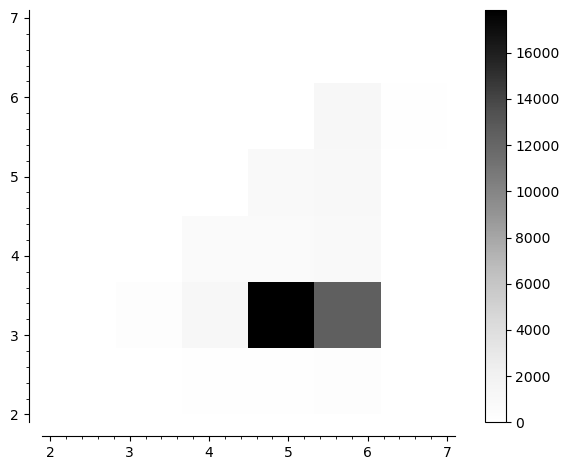

In [96]:
import numpy as np
"""
GenData=load("GenDataDict.sobj")
ShadowData=load("ShadowData.sobj")
OldData=load("OldData.sobj")
"""
Coeffs=[2,3,4,5,6,-1]
l=len(Coeffs)
testVal=True
r=0
VisualFSASize=np.zeros((6,6,6),dtype="int")
VisualShadowSize=np.zeros((6,6,6),dtype="int")
VisualTimes=np.zeros((6,6,6),dtype="int")
VisualFSADiff=np.zeros((6,6,6),dtype="int")
for i in range(l):
    for j in range(i,l):
        for k in range(j,l):
            print((i,j,k))
            VisualFSASize[i,j,k]=len((GenData[(Coeffs[i],Coeffs[j],Coeffs[k])][0]).states())
            VisualFSADiff[i,j,k]=len((OldData[(Coeffs[i],Coeffs[j],Coeffs[k])][0]).states())-len((GenData[(Coeffs[i],Coeffs[j],Coeffs[k])][0]).states())
            VisualShadowSize[i,j,k]=len(GenData[(Coeffs[i],Coeffs[j],Coeffs[k])][3])
            VisualTimes[i,j,k]=GenData[(Coeffs[i],Coeffs[j],Coeffs[k])][4]
plot(matrix(VisualFSASize[0]),colorbar=True,xrange=(2,7),yrange=(2,7))

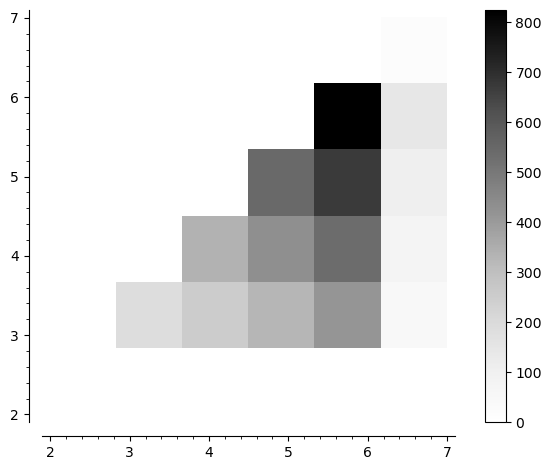

In [97]:
plot(matrix(VisualFSASize[1]),colorbar=True,xrange=(2,7),yrange=(2,7))

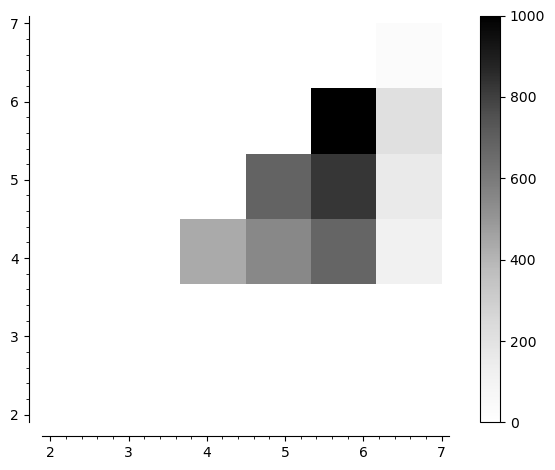

In [98]:
plot(matrix(VisualFSASize[2]),colorbar=True,xrange=(2,7),yrange=(2,7))

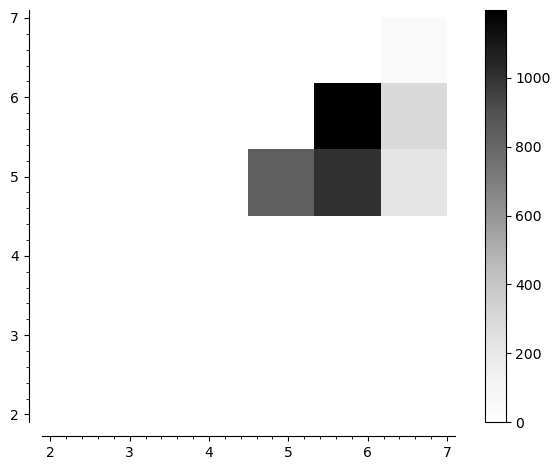

In [99]:
plot(matrix(VisualFSASize[3]),colorbar=True,xrange=(2,7),yrange=(2,7))

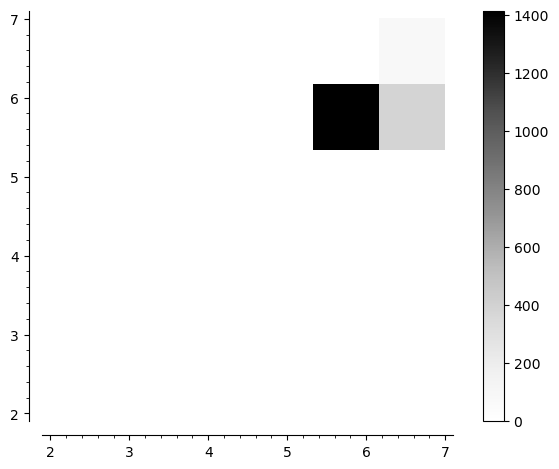

In [100]:
plot(matrix(VisualFSASize[4]),colorbar=True,xrange=(2,7),yrange=(2,7))

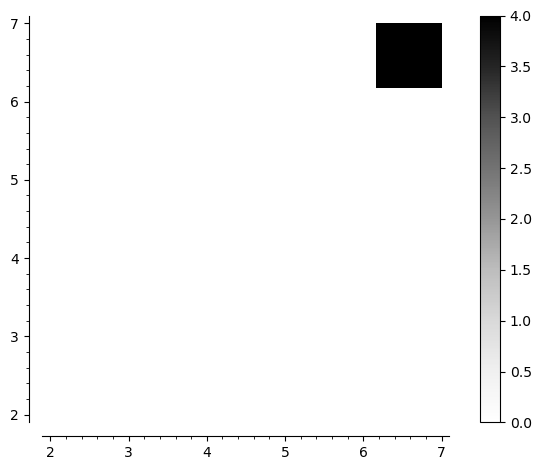

In [101]:
plot(matrix(VisualFSASize[5]),colorbar=True,xrange=(2,7),yrange=(2,7))

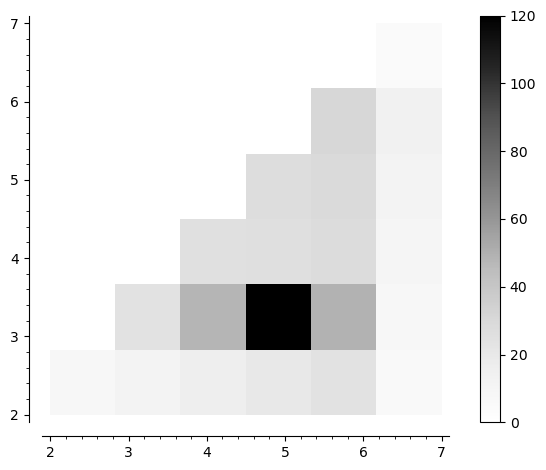

In [102]:
plot(matrix(VisualShadowSize[0]),colorbar=True,xrange=(2,7),yrange=(2,7))

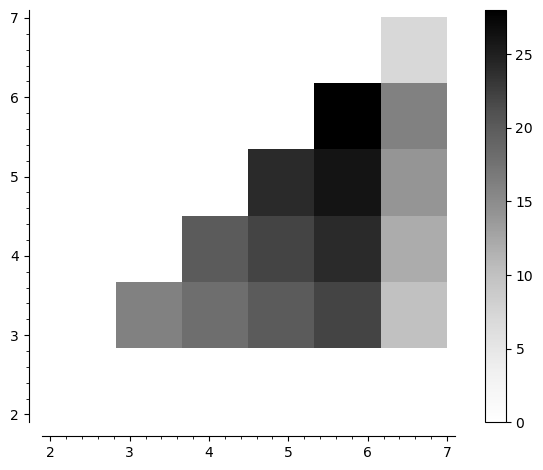

In [103]:
plot(matrix(VisualShadowSize[1]),colorbar=True,xrange=(2,7),yrange=(2,7))

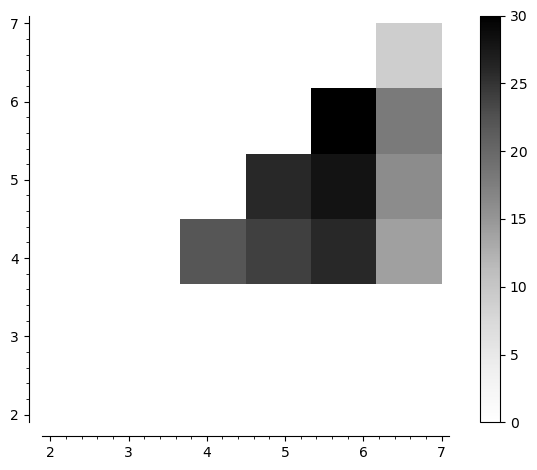

In [104]:
plot(matrix(VisualShadowSize[2]),colorbar=True,xrange=(2,7),yrange=(2,7))

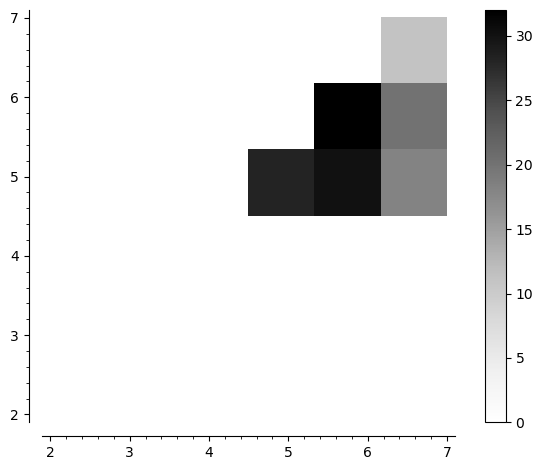

In [105]:
plot(matrix(VisualShadowSize[3]),colorbar=True,xrange=(2,7),yrange=(2,7))

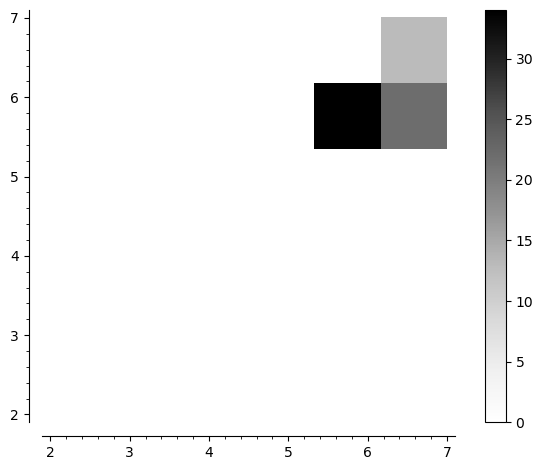

In [106]:
plot(matrix(VisualShadowSize[4]),colorbar=True,xrange=(2,7),yrange=(2,7))

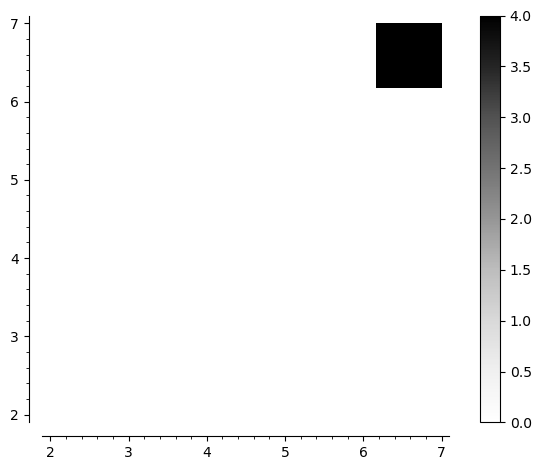

In [107]:
plot(matrix(VisualShadowSize[5]),colorbar=True,xrange=(2,7),yrange=(2,7))

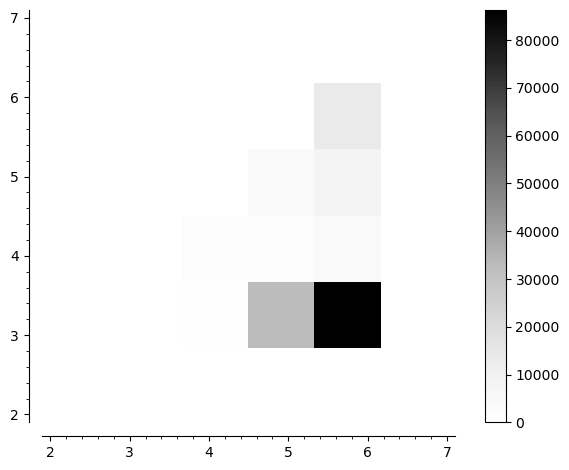

In [108]:
plot(matrix(VisualFSADiff[0]),colorbar=True,xrange=(2,7),yrange=(2,7))

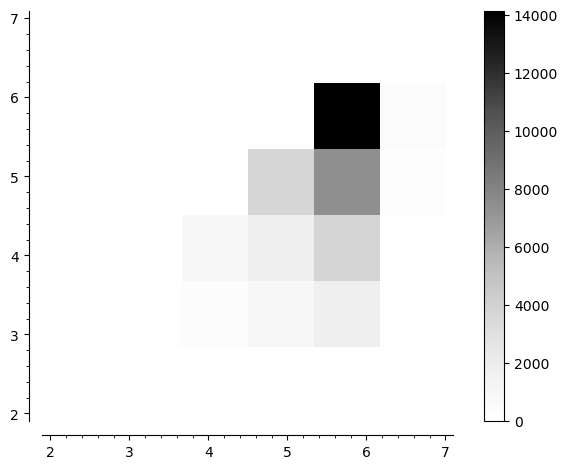

In [109]:
plot(matrix(VisualFSADiff[1]),colorbar=True,xrange=(2,7),yrange=(2,7))

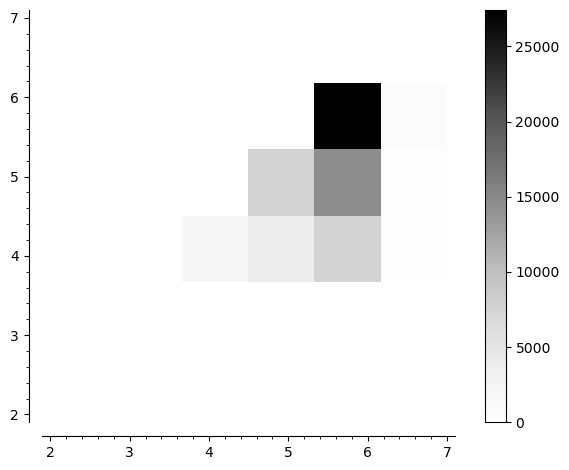

In [110]:
plot(matrix(VisualFSADiff[2]),colorbar=True,xrange=(2,7),yrange=(2,7))

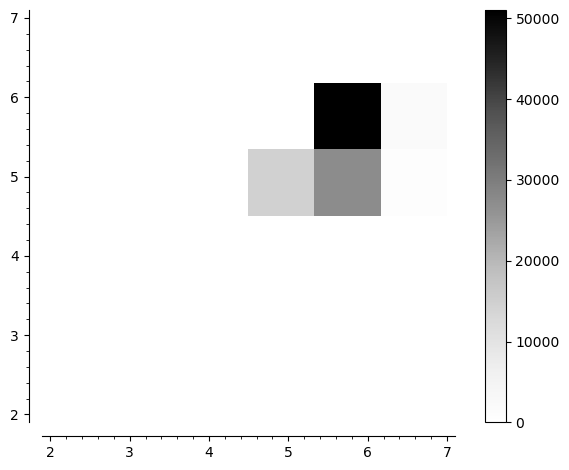

In [111]:
plot(matrix(VisualFSADiff[3]),colorbar=True,xrange=(2,7),yrange=(2,7))

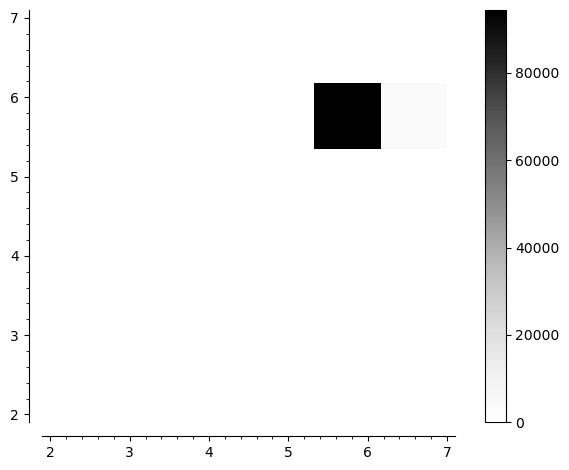

In [112]:
plot(matrix(VisualFSADiff[4]),colorbar=True,xrange=(2,7),yrange=(2,7))

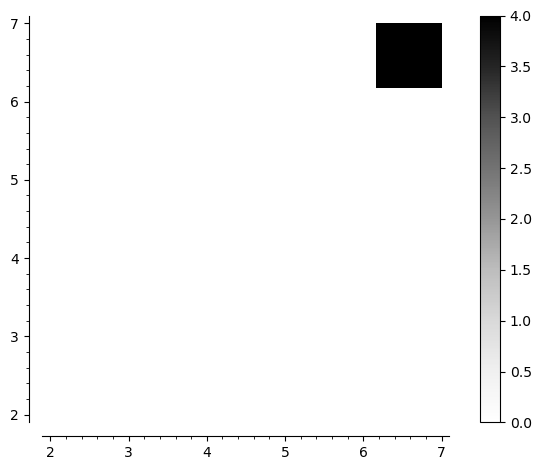

In [113]:
plot(matrix(VisualFSADiff[5]),colorbar=True,xrange=(2,7),yrange=(2,7))

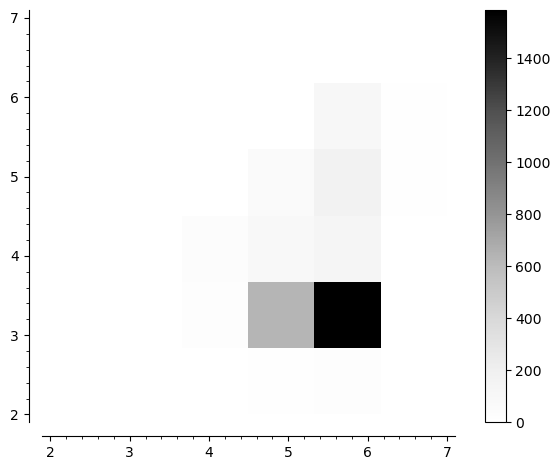

In [114]:
plot(matrix(VisualTimes[0]),colorbar=True,xrange=(2,7),yrange=(2,7))

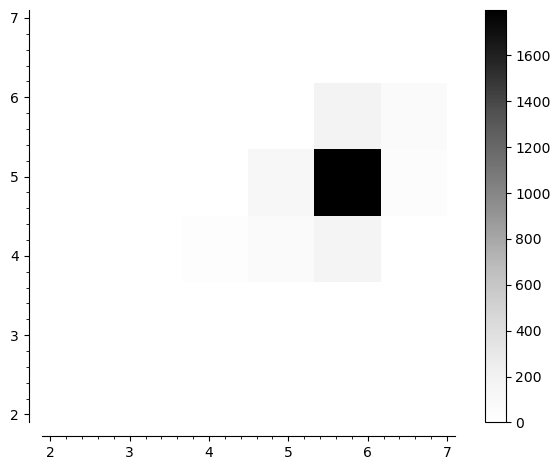

In [115]:
plot(matrix(VisualTimes[2]),colorbar=True,xrange=(2,7),yrange=(2,7))

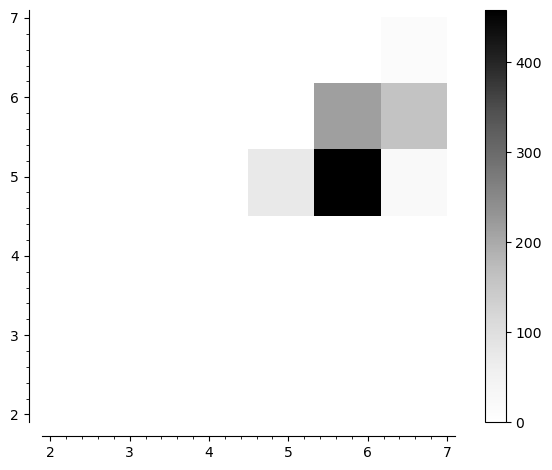

In [116]:
plot(matrix(VisualTimes[3]),colorbar=True,xrange=(2,7),yrange=(2,7))

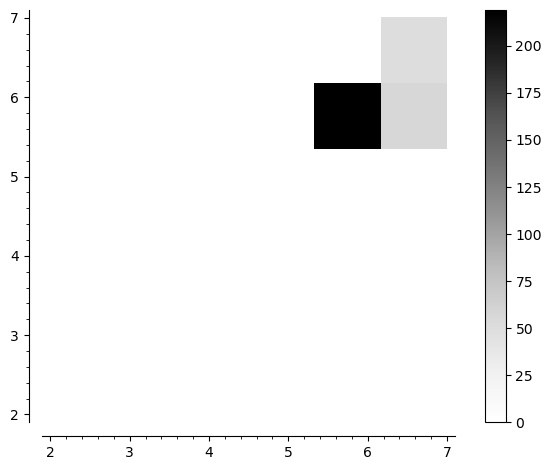

In [117]:
plot(matrix(VisualTimes[4]),colorbar=True,xrange=(2,7),yrange=(2,7))

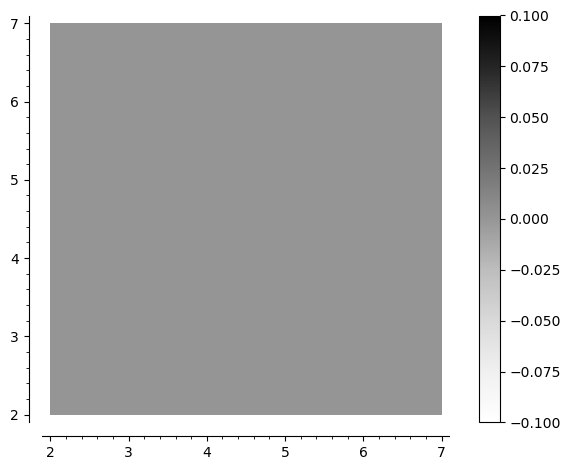

In [118]:
plot(matrix(VisualTimes[5]),colorbar=True,xrange=(2,7),yrange=(2,7))